# Lab: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)
By Kerrian Le Bars

## Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import joblib
from pathlib import Path
import optuna

c:\Users\kerri\anaconda3\envs\climate_risk\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 1. Data Setup and Exploration
*Estimated time: 30–40 min*

### Objective  
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the GIST Steel dataset. 
- Display basic info (shape, column names, missing values, and data types).  
- Identify the target variable (production) and key features (capacity, ...).

> *Markdown prompt:*  
Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?

---

In [2]:
# Set the file path
file_path = "Plant-level-data-Global-Iron-and-Steel-Tracker.xlsx"

# Load all necessary sheets
sheets = ["Plant data", "Plant capacities and status", "Plant production"]
dfs = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in sheets}

# Check that 'Plant ID' exists in each dataframe
for name, df in dfs.items():
    if 'Plant ID' not in df.columns:
        raise ValueError(f"'Plant ID' missing in sheet '{name}'")

# Function to select columns to merge
def select_merge_cols(base_df, new_df):
    cols = [col for col in new_df.columns if col not in base_df.columns or col == 'Plant ID']
    return new_df[cols]

# Merge the DataFrames with inner join to keep only the factories present in the 3 datasets
df_merged = dfs["Plant data"]
for sheet in sheets[1:]:
    df_merged = pd.merge(df_merged, 
                         select_merge_cols(df_merged, dfs[sheet]), 
                         on='Plant ID', 
                         how='inner')

In [3]:
# Display information about the merged dataset
print("=== Merged Dataset Information ===")
print(f"Total number of rows: {df_merged.shape[0]}")
print(f"Total number of columns: {df_merged.shape[1]}")
print(f"Number of unique Plant IDs: {df_merged['Plant ID'].nunique()}")
print(f"Number of duplicate Plant IDs: {df_merged.duplicated(subset='Plant ID').sum()}")

# Preview the dataset
print("\nPreview of the first rows:")
df_merged.head()

=== Merged Dataset Information ===
Total number of rows: 3243
Total number of columns: 61
Number of unique Plant IDs: 476
Number of duplicate Plant IDs: 2767

Preview of the first rows:


,Plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM ID,Owner PermID,SOE Status,...,Nominal BF capacity (ttpa),Nominal DRI capacity (ttpa),Other/unspecified iron capacity (ttpa),Type of production,2019,2020,2021,2022,2023,2024
0,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,Crude steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
1,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,BOF steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
2,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,EAF steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
3,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,Iron production (ttpa),560,unknown,unknown,unknown,unknown,unknown
4,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,BF iron production (ttpa),560,unknown,unknown,unknown,unknown,unknown


For this analysis, we focus exclusively on steel production facilities that are currently operational. Accordingly, we selected only the plants with an operational status in our dataset.

In [4]:
# Filter only operational plants
operating_plants = df_merged[df_merged['Status'].str.lower() == 'operating'].reset_index(drop=True)

# Dataset shape
num_rows, num_cols = operating_plants.shape
print(f"Operational plants dataset shape: {num_rows} rows x {num_cols} columns")

# Count unique Plant IDs
unique_plants = operating_plants['Plant ID'].nunique()
print(f"Number of unique operational plants: {unique_plants:,}")

Operational plants dataset shape: 1566 rows x 61 columns
Number of unique operational plants: 423


In [5]:
# Replace 'unknown' (case-insensitive) with NaN
pd.set_option('future.no_silent_downcasting', True)
operating_plants = operating_plants.replace(to_replace=r'(?i)^unknown$', value=np.nan, regex=True)

# Create summary table
summary_table = pd.DataFrame({
    "Column Name": operating_plants.columns,
    "Data Type": operating_plants.dtypes.values,
    "Missing Values": operating_plants.isnull().sum().values,
    "Missing (%)": (operating_plants.isnull().sum() / len(operating_plants) * 100).round(2).values
})

# Display the summary table
print("=== Operating Plants Dataset Summary (including 'unknown' as missing) ===")
display(summary_table)

=== Operating Plants Dataset Summary (including 'unknown' as missing) ===


,Column Name,Data Type,Missing Values,Missing (%)
0,Plant ID,object,0,0.00
1,Plant name (English),object,0,0.00
2,Plant name (other language),object,628,40.10
3,Other plant names (English),object,463,29.57
4,Other plant names (other language),object,1089,69.54
...,...,...,...,...
56,2020,object,819,52.30
57,2021,object,881,56.26
58,2022,object,844,53.90
59,2023,object,843,53.83


Our preliminary analysis highlights several data quality issues that must be addressed before proceeding with the modeling process:

1. **High Proportion of Missing Values:**

    - Several columns exhibit substantial missingness, with some exceeding 70% null entries.
    - Such extensive gaps in the data may compromise the robustness and reliability of subsequent analyses.

2. **Inconsistent Data Types:**

    - All columns are currently stored as object (string) types.
    - This indicates potential inconsistencies in data representation that must be corrected to enable accurate computation and modeling.

3. **Necessary Data Cleaning Steps:**

    - Appropriate imputation or removal strategies will be applied to handle missing values.
    - Data type conversions will be performed to ensure numerical and categorical variables are properly formatted.
    - Validation checks will be implemented to verify data consistency and integrity.

Addressing these issues is essential to ensure the validity, reliability, and overall quality of our subsequent analysis.

For this predictive modeling task, our focus is on forecasting crude steel production across manufacturing facilities. The analysis will:

- Define crude steel output as the primary target variable.
- Emphasize production-related features and their principal determinants.
- Exclude variables unrelated to the production process to avoid noise and redundancy.
- Maintain a clear focus on factors that directly influence steel production.

This focused approach is designed to enhance both the accuracy and interpretability of our forecasting models, ensuring that the results remain directly relevant to operational and strategic decision-making.

In [6]:
# Filter for crude steel production plants
crude_steel_plants = operating_plants[
    operating_plants['Type of production'].str.lower() == 'crude steel production (ttpa)'
].reset_index(drop=True)

# Dataset shape
num_rows, num_cols = crude_steel_plants.shape
print(f"Crude steel production plants dataset shape: {num_rows} rows x {num_cols} columns")

# Count unique Plant IDs
unique_plants = crude_steel_plants['Plant ID'].nunique()
print(f"Number of unique crude steel production plants: {unique_plants:,}")

# Optional preview
print("\nPreview of crude steel production plants:")
crude_steel_plants.head()

Crude steel production plants dataset shape: 411 rows x 61 columns
Number of unique crude steel production plants: 411

Preview of crude steel production plants:


,Plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM ID,Owner PermID,SOE Status,...,Nominal BF capacity (ttpa),Nominal DRI capacity (ttpa),Other/unspecified iron capacity (ttpa),Type of production,2019,2020,2021,2022,2023,2024
0,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5.000942e+09,Full,...,1500.0,NaN,NaN,Crude steel production (ttpa),NaN,NaN,NaN,NaN,NaN,NaN
1,P100000120441,Tosyali Algerie Oran steel plant,شركة توسيالي الجزائرية التركية للحديد والصلب,NaN,Tosyali Algérie,Tosyali Ironsteel Industry Algerie SpA,NaN,E100000131071,5.074197e+09,NaN,...,NaN,5000.0,NaN,Crude steel production (ttpa),NaN,NaN,NaN,NaN,NaN,NaN
2,P100000120006,ArcelorMittal Acindar Villa Constitución steel...,Planta siderúrgica Acindar,NaN,NaN,Acindar Industria Argentina de Aceros SA,NaN,E100001010109,4.295856e+09,NaN,...,NaN,600.0,NaN,Crude steel production (ttpa),1100,800,1252,1174,1100,NaN
3,P100000120009,Gerdau Sipar Pérez steel plant,Planta siderúrgica Gerdau Sipar Pérez,NaN,Gerdau Ludueña,Sipar Aceros SA,NaN,E100001010274,5.035931e+09,NaN,...,NaN,NaN,NaN,Crude steel production (ttpa),167,182,219,372,356,NaN
4,P100000120007,TenarisSiderca Campana steel plant,Planta siderúrgica TenarisSiderca,Tenaris Siderca Seamless Tubes Mill,"Dálmine Siderca (predecessor), Dálmine Safta (...",Siderca SAIC,NaN,E100000001765,4.295856e+09,NaN,...,NaN,960.0,NaN,Crude steel production (ttpa),878,694,873,922,910,NaN


We remove all columns that are either irrelevant to our prediction task, redundant, or contain excessive missing values. For instance, the ‘Start date’ and ‘Plant age’ columns convey the same information, making one of them unnecessary. Similarly, the 2024 column is excluded due to its 99% missing values. In addition, variables related to plant ownership or iron production are considered insufficiently relevant, as our objective is to predict crude steel production.

In [7]:
# Convert column names to strings
crude_steel_plants.columns = crude_steel_plants.columns.astype(str)

# List of columns to drop
cols_to_drop = [

    # Plant and owner info
    "Plant name (English)", "Plant name (other language)", "Other plant names (English)", "Other plant names (other language)",
    "Owner", "Owner (other language)", "Owner GEM ID", "Owner PermID", "SOE Status",
    "Parent", "Parent GEM ID", "Parent PermID", "Status", "Type of production", "Main production equipment",

    # Location info
    "Country/Area", "Location address", "Municipality", "Other language location address", 
    "Coordinates", "Coordinate accuracy", "GEM wiki page", "Subnational unit (province/state)",

    # Dates
    "Announced date", "Construction date", "Pre-retirement announcement date", 
    "Idled date", "Retired date", "Plant age (years)",

    # Capacities and products
    "Ferronickel capacity (ttpa)", "Sinter plant capacity (ttpa)", "Coking plant capacity (ttpa)",
    "Pelletizing plant capacity (ttpa)", "Category steel product", "Steel products", "Steel sector end users",

    # Iron production
    "Nominal iron capacity (ttpa)", "Nominal BF capacity (ttpa)", "Nominal DRI capacity (ttpa)",
    "Other/unspecified iron capacity (ttpa)",

    # Steel production
    "2024",

    # Sources
    "Power source", "Iron ore source", "Met coal source"
]

# Determine which columns actually exist in the dataset
existing_cols_to_drop = [col for col in cols_to_drop if col in crude_steel_plants.columns]

# Drop the columns
crude_steel_plants = crude_steel_plants.drop(columns=existing_cols_to_drop)

# Print summary
print(f"Dropped columns: {len(existing_cols_to_drop)}")
print(f"Cleaned dataset: {crude_steel_plants.shape[1]} remaining columns, {crude_steel_plants.shape[0]} rows.\n")

# Preview the cleaned dataset
crude_steel_plants.head()

Dropped columns: 44
Cleaned dataset: 17 remaining columns, 411 rows.



,Plant ID,Region,Start date,Workforce size,ISO 14001,ISO 50001,ResponsibleSteel Certification,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Nominal OHF steel capacity (ttpa),Other/unspecified steel capacity (ttpa),2019,2020,2021,2022,2023
0,P100000120440,Africa,1969,5748.0,NaN,NaN,No,2150,350.0,1800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P100000120441,Africa,2013,8000.0,Yes,NaN,No,6200,NaN,6200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P100000120006,Central & South America,1946,1624.0,2020,NaN,No,2000,NaN,2000.0,NaN,NaN,1100,800,1252,1174,1100
3,P100000120009,Central & South America,2017,787.0,2022,NaN,No,650,NaN,650.0,NaN,NaN,167,182,219,372,356
4,P100000120007,Central & South America,1960-07-25 00:00:00,2993.0,2022-07-19 00:00:00,2017-07-22 00:00:00,No,1720,NaN,1720.0,NaN,NaN,878,694,873,922,910


For our prediction task, we retained variables related to the production capacities of crude steel plants, their historical production data from 2019 to 2023, the age of the facilities, their geographical location, the number of employees, and information regarding their environmental certifications.

More specifically, we selected crude steel production in 2023 (and potentially in subsequent years) as the target variable for our prediction. The variables expected to exert the greatest influence on crude steel output include historical production levels, plant capacity, and the number of employees. Nonetheless, additional factors such as environmental certifications may provide complementary insights, helping the model capture more complex and nuanced patterns within the data.

### **Task 1.2 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).  
- Check for outliers or incorrect entries in numerical columns.  
- Apply transformations if needed (e.g., log-transform for skewed distributions).

> *Markdown prompt:*  
Explain your cleaning choices. Why did you treat the missing or skewed data in that way?

---

In [8]:
# Compute missing and 'unknown' per column
missing_or_unknown = crude_steel_plants.isnull().sum()

# Print results by column
print("=== Missing or Unknown Values per Column ===")
for col, count in missing_or_unknown.items():
    print(f"{col}: {count}")

=== Missing or Unknown Values per Column ===
Plant ID: 0
Region: 0
Start date: 5
Workforce size: 22
ISO 14001: 62
ISO 50001: 227
ResponsibleSteel Certification: 0
Nominal crude steel capacity (ttpa): 12
Nominal BOF steel capacity (ttpa): 241
Nominal EAF steel capacity (ttpa): 170
Nominal OHF steel capacity (ttpa): 410
Other/unspecified steel capacity (ttpa): 386
2019: 205
2020: 173
2021: 181
2022: 167
2023: 158


First, we decided to remove factories with missing values in the Nominal crude steel capacity column because this variable is essential for our analysis. Without this information, it is impossible to accurately assess the production potential of the factory or to include it reliably in the predictive model. Imputing these values could introduce significant bias, as capacity is a fundamental determinant of production output. Therefore, dropping these rows ensures the integrity and reliability of our dataset.

In [9]:
# First, convert the column to numeric, coercing errors into NaN
crude_steel_plants['Nominal crude steel capacity (ttpa)'] = pd.to_numeric(
    crude_steel_plants['Nominal crude steel capacity (ttpa)'], errors='coerce'
)

# Now drop rows where it is NaN
crude_steel_plants = crude_steel_plants.dropna(subset=['Nominal crude steel capacity (ttpa)'])

print(f"Rows remaining: {crude_steel_plants.shape[0]}")

Rows remaining: 398


Since factories do not all produce the same type of crude steel, several nominal sub-capacity fields contain missing values. To clean the dataset, we imputed these missing values with zeros and verified that the sum of the nominal sub-capacities equals the total nominal capacity, thereby ensuring data consistency and integrity. If this condition holds, the imputations will not affect the validity of the model or introduce bias.

In [10]:
# List of capacity columns
capacity_cols = [
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    "Nominal OHF steel capacity (ttpa)",
    "Other/unspecified steel capacity (ttpa)",
    "Nominal crude steel capacity (ttpa)"
]

# Convert all relevant columns to numeric (coerce errors -> NaN)
for col in capacity_cols:
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')

# Replace NaN with zeros in the four component columns
component_cols = capacity_cols[:-1]  # all except total
crude_steel_plants[component_cols] = crude_steel_plants[component_cols].fillna(0)

# Calculate total from components
crude_steel_plants["Calculated total capacity"] = crude_steel_plants[component_cols].sum(axis=1)

# Compare calculated vs reported total
comparison = (
    crude_steel_plants["Calculated total capacity"].round(2)
    == crude_steel_plants["Nominal crude steel capacity (ttpa)"].round(2)
)

crude_steel_plants.drop(columns=["Calculated total capacity"], inplace=True)

# Summary stats
matches = comparison.sum()
total = len(comparison)
print(f"Matching rows: {matches:,} out of {total:,} ({matches/total*100:.2f}%)")

# Inspect mismatches if any
mismatched = crude_steel_plants[~comparison]
print(f"Mismatched rows: {len(mismatched):,}")

Matching rows: 398 out of 398 (100.00%)
Mismatched rows: 0


Having verified the integrity of the factories’ capacity data, we decided to simplify the prediction task and enhance interpretability by retaining only the total nominal capacity of each factory, while removing the individual sub-capacity variables.

In [11]:
cols_to_drop = ["Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    "Nominal OHF steel capacity (ttpa)",
    "Other/unspecified steel capacity (ttpa)"]

crude_steel_plants.drop(columns=cols_to_drop, inplace=True)
crude_steel_plants.head()

,Plant ID,Region,Start date,Workforce size,ISO 14001,ISO 50001,ResponsibleSteel Certification,Nominal crude steel capacity (ttpa),2019,2020,2021,2022,2023
0,P100000120440,Africa,1969,5748.0,NaN,NaN,No,2150.0,NaN,NaN,NaN,NaN,NaN
1,P100000120441,Africa,2013,8000.0,Yes,NaN,No,6200.0,NaN,NaN,NaN,NaN,NaN
2,P100000120006,Central & South America,1946,1624.0,2020,NaN,No,2000.0,1100,800,1252,1174,1100
3,P100000120009,Central & South America,2017,787.0,2022,NaN,No,650.0,167,182,219,372,356
4,P100000120007,Central & South America,1960-07-25 00:00:00,2993.0,2022-07-19 00:00:00,2017-07-22 00:00:00,No,1720.0,878,694,873,922,910


To address the issue of missing data on factory age ('Start date') and payroll ('Workerforce size'), we applied median imputation, as it is robust to outliers and preserves a value distribution consistent with that of the overall population. Moreover, since the proportion of missing values is low, this approach minimizes the risk of introducing bias into the dataset. Deleting these columns would have resulted in the loss of valuable information. By using median imputation, we retain all available observations, maintain dataset completeness, and ensure that the predictive model can leverage the maximum amount of relevant data for training.

In [12]:
# Extract first 4 characters and convert to numeric to get only the years
crude_steel_plants["Start date"] = pd.to_numeric(
    crude_steel_plants["Start date"].astype(str).str[:4],
    errors='coerce')

cols_to_impute = ["Start date", "Workforce size"]

for col in cols_to_impute:
    # Convert to numeric (safety check)
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')
    
    # Count missing values before imputation
    missing_before = crude_steel_plants[col].isna().sum()
    print(f"{col}: missing values before imputation = {missing_before}")
    
    # Calculate median while ignoring NaN
    median_value = crude_steel_plants[col].median()
    
    # Replace NaN with median
    crude_steel_plants[col] = crude_steel_plants[col].fillna(median_value)
    
    print(f"{col}: missing values filled with median = {median_value}")

Start date: missing values before imputation = 4
Start date: missing values filled with median = 1984.0
Workforce size: missing values before imputation = 19
Workforce size: missing values filled with median = 2294.0


We also decided to remove factories with no recorded production history, as our objective is to predict crude steel production in 2023. Imputing an entire production history for these factories would introduce excessive uncertainty and could significantly bias the model. By excluding such observations, we ensure that the training data reflects actual production behavior and maintains the reliability of the predictive analysis.

In [13]:
# List of year columns
year_cols = ["2019", "2020", "2021", "2022", "2023"]

# Convert to numeric and coerce errors to NaN
for col in year_cols:
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')

# Replace "unknown" or values > 0 with NaN
# (assuming you meant you want to remove unrealistic values > 0? If not, adjust condition)
# If you want only "unknown" to be NaN, you can skip the >0 part
crude_steel_plants[year_cols] = crude_steel_plants[year_cols].apply(
    lambda x: np.nan if (isinstance(x, str)) else x
)

# Drop rows where all the year columns are NaN
crude_steel_plants = crude_steel_plants.dropna(subset=year_cols, how="all")

# Check results
print(f"Dataset shape after cleaning year columns: {crude_steel_plants.shape}")
print(f"Remaining rows: {len(crude_steel_plants)}")

Dataset shape after cleaning year columns: (383, 13)
Remaining rows: 383


For the remaining missing values in the production history, we opted to impute them using the mean of the available values for each factory. Removing all factories with incomplete production data would not be feasible, as it would considerably reduce the dataset and lead to substantial information loss. Although mean imputation does not fully capture the underlying variability of the data, it allows us to preserve the overall production trends and maintain a representative sample for model training.

In [14]:
# Ensure columns exist and are numeric
for col in year_cols:
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')

# Impute NaN per row by the mean of the available years
crude_steel_plants[year_cols] = crude_steel_plants[year_cols].apply(
    lambda row: row.fillna(row.mean()), axis=1
)

# Optional: check if any NaN remain
remaining_nans = crude_steel_plants[year_cols].isnull().sum().sum()
print(f"Total remaining NaN in year columns after row-wise imputation: {remaining_nans}")

Total remaining NaN in year columns after row-wise imputation: 0


Finally, we addressed the columns related to environmental certifications. Our exploration revealed that these columns contained numerous diverse and missing values. To improve consistency, we simplified the data by retaining only a binary indicator of whether a factory has a certification or not. We further assumed that missing information indicated the absence of certification, as factories with such credentials are typically listed in public databases, especially for ISO certifications. While this assumption is a hypothesis, we believe it provides the most consistent approach and minimizes potential bias in the dataset.

In [15]:
def clean_iso_column(df, column_name):
    """Cleans an ISO column by replacing 'expired' and NaN with 'No', and all other values with 'Yes'"""
    # Display unique values before cleaning
    unique_values = df[column_name].dropna().unique()
    print(f"\n=== {column_name} ===")
    print("Unique values before cleaning:")
    print(unique_values[:min(5, len(unique_values))])  # Shows up to 5 values
    print(f"Total unique values: {len(unique_values)}")
    
    # Apply cleaning
    df[column_name] = df[column_name].apply(
        lambda x: 'No' if pd.isna(x) or str(x).lower() == 'expired' else 'Yes'
    )
    
    # Display results
    print("\nSummary after cleaning:")
    value_counts = df[column_name].value_counts(dropna=False)
    print(value_counts.to_string())
    print(f"Total: {len(df)} entries")
    print("=" * 50)

# Apply to ISO 14001
clean_iso_column(crude_steel_plants, 'ISO 14001')

# Apply to ISO 50001
clean_iso_column(crude_steel_plants, 'ISO 50001')


=== ISO 14001 ===
Unique values before cleaning:
[2020 2022 datetime.datetime(2022, 7, 19, 0, 0)
 datetime.datetime(2022, 7, 22, 0, 0) 'Expired']
Total unique values: 150

Summary after cleaning:
ISO 14001
Yes    303
No      80
Total: 383 entries

=== ISO 50001 ===
Unique values before cleaning:
[datetime.datetime(2017, 7, 22, 0, 0) 'Yes' 2022 2024 'Expired']
Total unique values: 97

Summary after cleaning:
ISO 50001
No     223
Yes    160
Total: 383 entries


In [16]:
# Display unique values before modification
print("Unique values before modification:")
print(crude_steel_plants['ResponsibleSteel Certification'].unique())

# Replace all non-null values that are not 'No' with 'Yes'
crude_steel_plants['ResponsibleSteel Certification'] = (
    crude_steel_plants['ResponsibleSteel Certification']
    .apply(lambda x: 'Yes' if pd.notna(x) and str(x).strip().lower() != 'no' else 'No')
)

# Display the count after cleaning
print("\nSummary after cleaning:")
print(crude_steel_plants['ResponsibleSteel Certification'].value_counts(dropna=False))

Unique values before modification:
['No' datetime.datetime(2022, 2, 1, 0, 0)
 datetime.datetime(2021, 7, 1, 0, 0) datetime.datetime(2023, 1, 16, 0, 0)
 datetime.datetime(2024, 10, 30, 0, 0)
 datetime.datetime(2022, 12, 20, 0, 0)
 datetime.datetime(2022, 1, 21, 0, 0) datetime.datetime(2024, 1, 11, 0, 0)
 datetime.datetime(2022, 5, 1, 0, 0) datetime.datetime(2021, 7, 19, 0, 0)
 datetime.datetime(2023, 12, 19, 0, 0)
 datetime.datetime(2022, 10, 28, 0, 0)
 datetime.datetime(2024, 1, 15, 0, 0) datetime.datetime(2022, 8, 1, 0, 0)
 datetime.datetime(2022, 10, 12, 0, 0)
 datetime.datetime(2022, 5, 13, 0, 0) datetime.datetime(2024, 9, 1, 0, 0)]

Summary after cleaning:
ResponsibleSteel Certification
No     359
Yes     24
Name: count, dtype: int64


We can now confirm that the dataset contains no missing values, allowing us to proceed with generating descriptive statistics for the numerical variables.

In [17]:
# Compute missing and 'unknown' per column
missing_or_unknown = crude_steel_plants.isnull().sum()

# Print results by column
print("=== Missing or Unknown Values per Column ===")
for col, count in missing_or_unknown.items():
    print(f"{col}: {count}")

=== Missing or Unknown Values per Column ===
Plant ID: 0
Region: 0
Start date: 0
Workforce size: 0
ISO 14001: 0
ISO 50001: 0
ResponsibleSteel Certification: 0
Nominal crude steel capacity (ttpa): 0
2019: 0
2020: 0
2021: 0
2022: 0
2023: 0


In [18]:
# Select only numeric columns
numeric_cols = crude_steel_plants.select_dtypes(include='number').columns.tolist()

# Basic summary to detect extreme values
summary = crude_steel_plants[numeric_cols].describe()
summary

,Start date,Workforce size,Nominal crude steel capacity (ttpa),2019,2020,2021,2022,2023
count,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000
mean,1974.289817,3992.971279,3128.093995,3217.660574,3202.956484,3256.183203,3195.832245,3222.985857
std,39.790447,5123.781686,3489.790484,6087.010369,6177.467532,6079.688786,6019.652220,6085.437176
min,1739.000000,32.000000,13.000000,5.000000,5.000000,5.000000,5.000000,5.000000
25%,1958.000000,747.500000,903.500000,617.500000,598.500000,650.750000,643.000000,652.625000
50%,1984.000000,2294.000000,1800.000000,1500.000000,1400.000000,1470.000000,1443.000000,1503.000000
75%,2002.000000,5317.500000,3750.000000,3668.500000,3615.000000,3762.750000,3589.500000,3541.500000
max,2023.000000,32364.000000,22999.000000,71819.000000,71819.000000,71819.000000,71819.000000,71819.000000


The Z-score method is an effective approach for detecting outliers, as it quantifies how many standard deviations each data point lies from the mean. This provides an objective criterion for identifying extreme values that could disproportionately influence the analysis. By setting a threshold at 3 standard deviations, we target values that are highly unlikely to occur under a normal distribution, approximately less than 0.3% of observations, ensuring that only genuinely anomalous points are flagged, rather than typical variability in the data.

In [19]:
z_scores = np.abs(stats.zscore(crude_steel_plants[numeric_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3)  # z-score threshold for outliers

# Total number of outliers per column
outliers_z = (outlier_mask.sum(axis=0))
print("Outliers detected using Z-score > 3: \n")
for col, count in zip(numeric_cols, outliers_z):
    print(f"{col}: {count}")

Outliers detected using Z-score > 3: 

Start date: 6
Workforce size: 9
Nominal crude steel capacity (ttpa): 10
2019: 3
2020: 4
2021: 4
2022: 3
2023: 4


Applying the Z-score method, we identified a few outliers in the dataset. To better understand their nature and assess whether they could adversely affect our analysis, we will generate histograms for the three columns with the highest number of outliers. This will help visualize the distribution and guide decisions on how to handle these extreme values.

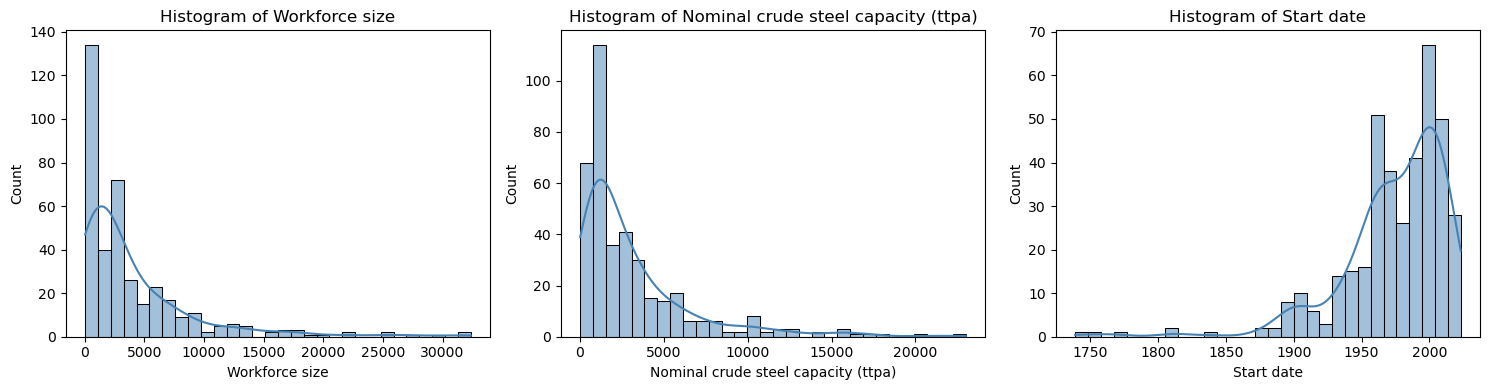

In [20]:
# Columns to plot
columns_to_plot = [
    "Workforce size",
    "Nominal crude steel capacity (ttpa)",
    "Start date"
]

# Create histograms
plt.figure(figsize=(15, 4))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(1, len(columns_to_plot), i)
    sns.histplot(crude_steel_plants[col], bins=30, kde=True, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    
plt.tight_layout()
plt.show()

Despite the presence of outliers, the data appears consistent and credible. For instance, some factories have exceptionally high production volumes and capacities, which naturally explains the outliers in the number of workers. Similarly, the dataset includes very old facilities (for example, a crude steel factory over 200 years old) which accounts for extreme values in the 'Start date' variable. Given that these outliers reflect genuine characteristics of the data, treating or removing them would risk distorting the dataset. Therefore, we conclude that no outlier treatment is necessary.

In [21]:
# Convert from wide to long format
crude_steel_plants = crude_steel_plants.melt(
    id_vars=[
        "Plant ID", "Start date", "Workforce size",
        "Nominal crude steel capacity (ttpa)",
        "ISO 14001", "ISO 50001", "ResponsibleSteel Certification",
        "Region"
    ],
    value_vars=year_cols,
    var_name="Year",
    value_name="Crude steel production (ttpa)"
)

# Convert Year to integer
crude_steel_plants['Year'] = crude_steel_plants['Year'].astype(int)

crude_steel_plants.head()

,Plant ID,Start date,Workforce size,Nominal crude steel capacity (ttpa),ISO 14001,ISO 50001,ResponsibleSteel Certification,Region,Year,Crude steel production (ttpa)
0,P100000120006,1946.0,1624.0,2000.0,Yes,No,No,Central & South America,2019,1100.0
1,P100000120009,2017.0,787.0,650.0,Yes,No,No,Central & South America,2019,167.0
2,P100000120007,1960.0,2993.0,1720.0,Yes,Yes,No,Central & South America,2019,878.0
3,P100000120008,1960.0,3274.0,3501.0,Yes,Yes,No,Central & South America,2019,2162.0
4,P100000120012,1928.0,3000.0,3200.0,No,No,Yes,Asia Pacific,2019,3013.0




### **Task 1.3 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).  
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.

> *Markdown prompt:*  
Document your new feature(s). What business or operational insight do they represent?

---


In [22]:
# Dynamic Plant Age
crude_steel_plants['Plant Age'] = (
    (crude_steel_plants['Year'] - crude_steel_plants['Start date']))

crude_steel_plants.drop(['Start date'], axis=1, inplace=True) # Remove the Start date column

In [23]:
# Capacity per Worker
crude_steel_plants['Capacity per Worker (ttpa per worker)'] = (
    crude_steel_plants['Nominal crude steel capacity (ttpa)'] / crude_steel_plants['Workforce size'])

# Certification Score
crude_steel_plants["Certification score"] = (
    (crude_steel_plants["ISO 14001"] == "Yes").astype(int) +
    (crude_steel_plants["ISO 50001"] == "Yes").astype(int) +
    (crude_steel_plants["ResponsibleSteel Certification"] == "Yes").astype(int))

In [24]:
# Sort by Plant and Year
crude_steel_plants = crude_steel_plants.sort_values(["Plant ID", "Year"])

# Compute Year-on-Year Growth (%)
crude_steel_plants["Annual Growth (%)"] = (
    crude_steel_plants.groupby("Plant ID")["Crude steel production (ttpa)"]
    .pct_change() * 100
)

# Compute Average Annual Growth and Volatility per Plant
growth_stats = (
    crude_steel_plants.groupby("Plant ID")[["Annual Growth (%)"]]
    .agg(
        Avg_Annual_Growth=("Annual Growth (%)", "mean"),
        Growth_Volatility=("Annual Growth (%)", "std")
    )
    .reset_index()
)

# Merge back to main dataframe
crude_steel_plants = crude_steel_plants.merge(growth_stats, on="Plant ID", how="left")

# Drop intermediate 'Annual Growth (%)'
crude_steel_plants.drop(columns=["Annual Growth (%)"], inplace=True)

# Fill missing values (plants with only one year)
crude_steel_plants[["Avg_Annual_Growth", "Growth_Volatility"]] = (
    crude_steel_plants[["Avg_Annual_Growth", "Growth_Volatility"]].fillna(0)
)

crude_steel_plants.head()

,Plant ID,Workforce size,Nominal crude steel capacity (ttpa),ISO 14001,ISO 50001,ResponsibleSteel Certification,Region,Year,Crude steel production (ttpa),Plant Age,Capacity per Worker (ttpa per worker),Certification score,Avg_Annual_Growth,Growth_Volatility
0,P100000120006,1624.0,2000.0,Yes,No,No,Central & South America,2019,1100.0,73.0,1.231527,1,4.173501,36.262576
1,P100000120006,1624.0,2000.0,Yes,No,No,Central & South America,2020,800.0,74.0,1.231527,1,4.173501,36.262576
2,P100000120006,1624.0,2000.0,Yes,No,No,Central & South America,2021,1252.0,75.0,1.231527,1,4.173501,36.262576
3,P100000120006,1624.0,2000.0,Yes,No,No,Central & South America,2022,1174.0,76.0,1.231527,1,4.173501,36.262576
4,P100000120006,1624.0,2000.0,Yes,No,No,Central & South America,2023,1100.0,77.0,1.231527,1,4.173501,36.262576


New Feature Documentation:
1. **Capacity per Worker (ttpa per worker)**

    This feature measures labor productivity at each factory, indicating how efficiently the workforce is utilized to produce crude steel. Higher values suggest that a factory achieves greater output per employee, which can reflect operational efficiency, automation, or economies of scale.

2. **Average Annual Growth (%) over 2019–2023**

    This feature captures the historical growth trend of each factory’s production. It provides a sense of the factory’s performance trajectory, enabling the model to differentiate between consistently expanding facilities and those with stagnant or declining output. This can help identify factors contributing to production growth and improve predictive accuracy for 2023 output.

3. **Growth Volatility over 2019-2023**

    This feature quantifies the variability or instability in a factory’s annual production growth over time. A higher volatility value indicates that the plant’s output fluctuates significantly from year to year, which may reflect operational uncertainty, sensitivity to market demand, or inconsistent capacity utilization. Conversely, low volatility suggests steady, predictable production levels. This feature helps the model account for production reliability and the potential risks associated with unstable operations.

4. **Certification Score**

    This composite indicator summarizes a plant’s level of environmental and sustainability compliance. It is calculated based on the number of certifications held by the factory: ISO 14001 (environmental management), ISO 50001 (energy management), and ResponsibleSteel certification (sustainability and governance). A higher score implies greater adherence to international standards, which may correlate with improved efficiency, modern management practices, or access to premium markets. This feature provides the model with an operational measure of sustainability maturity.

In [25]:
# Identify categorical columns (object or category type)
categorical_cols = crude_steel_plants.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Identify numeric columns
numeric_cols = crude_steel_plants.select_dtypes(include=['number']).columns.tolist()
print("Numeric columns:", numeric_cols)

Categorical columns: ['Plant ID', 'ISO 14001', 'ISO 50001', 'ResponsibleSteel Certification', 'Region']
Numeric columns: ['Workforce size', 'Nominal crude steel capacity (ttpa)', 'Year', 'Crude steel production (ttpa)', 'Plant Age', 'Capacity per Worker (ttpa per worker)', 'Certification score', 'Avg_Annual_Growth', 'Growth_Volatility']


In our modeling process, it is necessary to transform categorical variables into numerical representations. To achieve this, we will use two encoding techniques: one-hot encoding and label encoding. We chose one-hot encoding for the 'Region' column, as it contains multiple categories without an inherent order. For the columns related to certifications, we applied label encoding, since these variables were deliberately treated as binary. This approach ensures that the numerical representation accurately reflects the nature of the categorical data, while preserving meaningful relationships for the model.

In [26]:
# One-hot encode categorical variables
encoded_df = pd.get_dummies(crude_steel_plants['Region'], drop_first=True)

# Drop original categorical columns and append encoded ones
crude_steel_plants = pd.concat(
    [crude_steel_plants.drop(columns='Region'), encoded_df],
    axis=1
)

# Create a label encoder instance
le = LabelEncoder()

# Apply label encoding directly to the specified columns
for col in ['ISO 14001', 'ISO 50001', 'ResponsibleSteel Certification']:
    if col in crude_steel_plants.columns:
        # Store original column for reference
        original_values = crude_steel_plants[col].copy()
        
        # Apply label encoding directly to the original column
        crude_steel_plants[col] = le.fit_transform(crude_steel_plants[col].astype(str))

print(f"Shape after encoding: {crude_steel_plants.shape}")
crude_steel_plants.head()

Shape after encoding: (1915, 19)


,Plant ID,Workforce size,Nominal crude steel capacity (ttpa),ISO 14001,ISO 50001,ResponsibleSteel Certification,Year,Crude steel production (ttpa),Plant Age,Capacity per Worker (ttpa per worker),Certification score,Avg_Annual_Growth,Growth_Volatility,Asia Pacific,Central & South America,Eurasia,Europe,Middle East,North America
0,P100000120006,1624.0,2000.0,1,0,0,2019,1100.0,73.0,1.231527,1,4.173501,36.262576,False,True,False,False,False,False
1,P100000120006,1624.0,2000.0,1,0,0,2020,800.0,74.0,1.231527,1,4.173501,36.262576,False,True,False,False,False,False
2,P100000120006,1624.0,2000.0,1,0,0,2021,1252.0,75.0,1.231527,1,4.173501,36.262576,False,True,False,False,False,False
3,P100000120006,1624.0,2000.0,1,0,0,2022,1174.0,76.0,1.231527,1,4.173501,36.262576,False,True,False,False,False,False
4,P100000120006,1624.0,2000.0,1,0,0,2023,1100.0,77.0,1.231527,1,4.173501,36.262576,False,True,False,False,False,False


Next, we will standardize the numerical data to improve model performance. To achieve this, we will apply a Min-Max scaling transformation, which rescales the values to a consistent range, typically between 0 and 1. This ensures that all features contribute proportionally to the model, prevents variables with larger scales from dominating, and facilitates faster and more stable convergence during training.

In [27]:
scaler = StandardScaler()

# Exclude 'Year' from numeric columns to scale
cols_to_scale = [col for col in numeric_cols if col != 'Year']

# Standardize numeric columns except 'Year'
crude_steel_plants[cols_to_scale] = scaler.fit_transform(crude_steel_plants[cols_to_scale])

# Check result
crude_steel_plants[numeric_cols].head()


,Workforce size,Nominal crude steel capacity (ttpa),Year,Crude steel production (ttpa),Plant Age,Capacity per Worker (ttpa per worker),Certification score,Avg_Annual_Growth,Growth_Volatility
0,-0.462953,-0.323678,2019,-0.348417,0.661152,-0.147797,-0.349072,0.006995,0.474262
1,-0.462953,-0.323678,2020,-0.397742,0.686301,-0.147797,-0.349072,0.006995,0.474262
2,-0.462953,-0.323678,2021,-0.323426,0.711450,-0.147797,-0.349072,0.006995,0.474262
3,-0.462953,-0.323678,2022,-0.336251,0.736598,-0.147797,-0.349072,0.006995,0.474262
4,-0.462953,-0.323678,2023,-0.348417,0.761747,-0.147797,-0.349072,0.006995,0.474262


In [28]:
# Save the cleaned dataset
crude_steel_plants.to_csv("crude_steel_plants_dataset.csv", index=False)

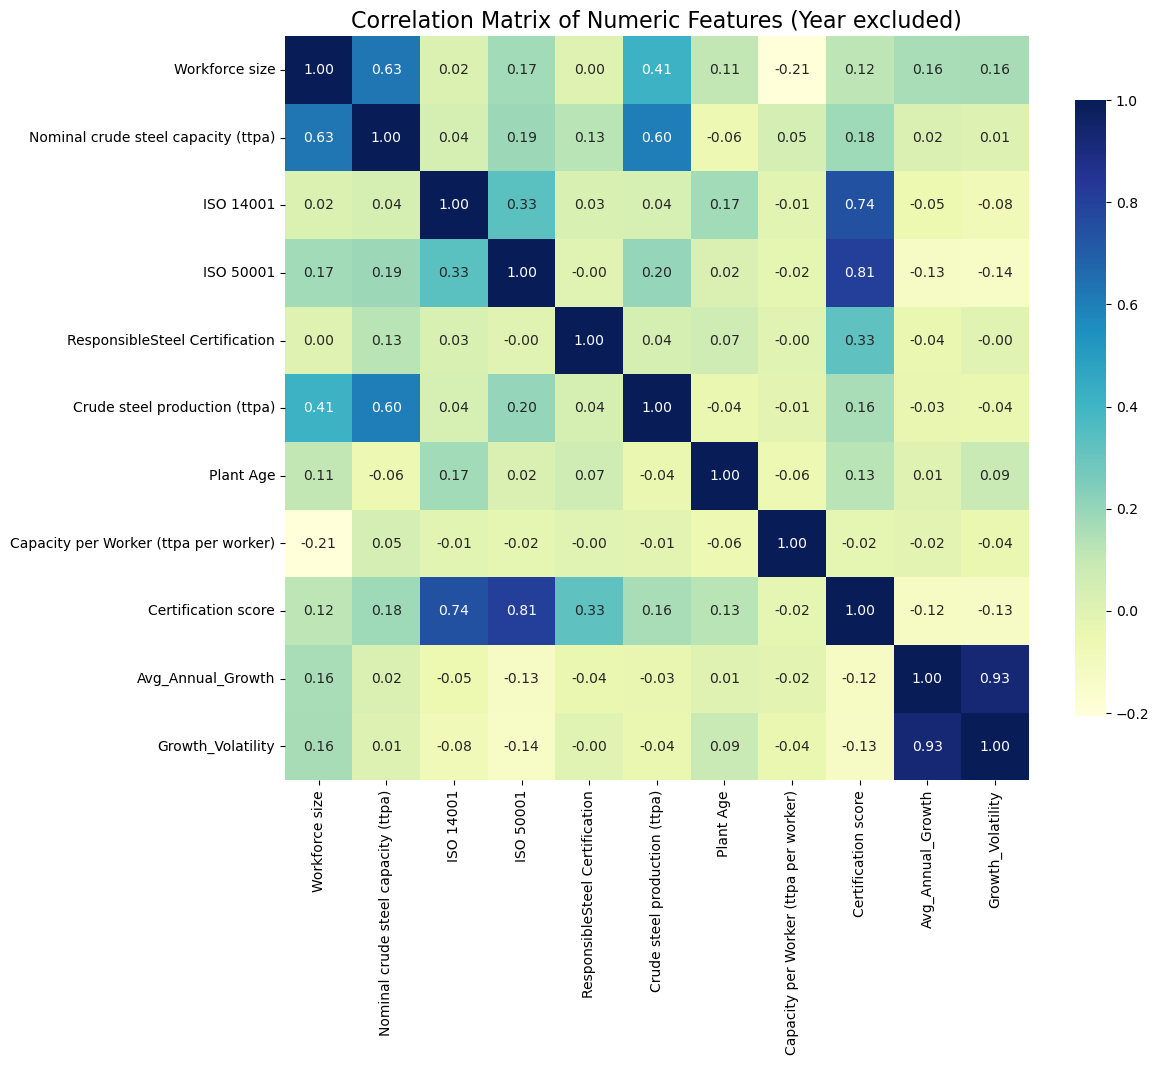

In [29]:
# Select only numeric columns and exclude 'Year'
numeric_cols = [col for col in crude_steel_plants.select_dtypes(include=['number']).columns 
                if col != 'Year']

# Compute Pearson correlation on selected numeric columns
corr_matrix = crude_steel_plants[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation coefficients
    fmt=".2f",         # 2 decimals
    cmap="YlGnBu",     # blue-green color map
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features (Year excluded)", fontsize=16)
plt.show()

## 2. Building Baseline & Linear Models
*Estimated time: 25–30 min*

### Objective  
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (e.g., mean or median production).  
- Measure RMSE or MAE compared to actual values.

> *Markdown prompt:*  
Why is it useful to have a baseline model before trying more complex ones?

---


In [30]:
# Target year
target_year = 2023
past_years = [2019, 2020, 2021, 2022]

# Get mean of previous years for each plant
past_means = crude_steel_plants[crude_steel_plants['Year'].isin(past_years)]\
    .groupby('Plant ID')['Crude steel production (ttpa)']\
    .mean()\
    .reset_index()\
    .rename(columns={'Crude steel production (ttpa)': 'predicted_production'})

# Get actual values for target year
actual_values = crude_steel_plants[crude_steel_plants['Year'] == target_year][
    ['Plant ID', 'Crude steel production (ttpa)']
].rename(columns={'Crude steel production (ttpa)': 'actual_production'})

# Merge predictions with actual values
results = pd.merge(
    actual_values,
    past_means,
    on='Plant ID',
    how='inner'  # Only include plants with data in both periods
)

# Compute RMSE and MAE
rmse = np.sqrt(mean_squared_error(
    results['actual_production'],
    results['predicted_production']
))
mae = mean_absolute_error(
    results['actual_production'],
    results['predicted_production']
)

print(f"{target_year} - Baseline prediction (mean of previous years)")
print(f"Number of plants: {len(results)}")
print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}")

# Show first few predictions vs actual
print("\nFirst few predictions vs actual:")
display(results.head())

2023 - Baseline prediction (mean of previous years)
Number of plants: 383
RMSE: 0.191, MAE: 0.037

First few predictions vs actual:


,Plant ID,actual_production,predicted_production
0,P100000120006,-0.348417,-0.351459
1,P100000120007,-0.379656,-0.390878
2,P100000120008,-0.163285,-0.188605
3,P100000120009,-0.470743,-0.490637
4,P100000120012,-0.007296,-0.007296


In machine learning, establishing a baseline model is a critical first step before developing more complex models. A baseline serves as a reference point, providing a minimum standard of performance against which more sophisticated models can be compared. For instance, in a regression problem, predicting the mean of the target variable can serve as a simple baseline. Having a baseline is useful for several reasons. 

First, it helps gauge the effectiveness of advanced models: if a complex model fails to outperform the baseline, it signals potential issues in feature engineering, model design, or data quality. Second, it prevents unnecessary complexity, ensuring that model development focuses on meaningful improvements rather than over-engineering. Third, a baseline facilitates debugging by revealing errors in data preprocessing, feature handling, or evaluation metrics. Finally, it sets realistic expectations for stakeholders and guides iterative model improvement by quantifying incremental gains.


### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.  
- Display coefficients and interpret their meaning.  
- Evaluate the model on training and test data.

> *Markdown prompt:*  
Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?

---


In [31]:
# Create a copy of the data for modeling
model_data = crude_steel_plants.copy()

# Define target year and past years
target_year = 2023
past_years = [2019, 2020, 2021, 2022]

# Create lagged production features
for year in past_years:
    lagged = model_data[model_data['Year'] == year][['Plant ID', 'Crude steel production (ttpa)']]\
        .rename(columns={'Crude steel production (ttpa)': f'prod_{year}'})
    model_data = pd.merge(model_data, lagged, on='Plant ID', how='left')

# Keep only target year for prediction
target_data = model_data[model_data['Year'] == target_year].copy()

# Define features (using only lagged production for pooled model)
feature_cols = [f'prod_{year}' for year in past_years]

# Add other numeric features if needed
numeric_cols = [
    'Workforce size', 'Nominal crude steel capacity (ttpa)',
    'Capacity per Worker (ttpa per worker)', 'Growth_Volatility',
    'Avg_Annual_Growth', 'Plant Age'
]

# Add certification and region dummies if available
categorical_cols = [
    'Certification score',
    'Asia Pacific', 'Central & South America', 'Eurasia', 
    'Europe', 'Middle East', 'North America'
]

# Select only existing columns
available_cols = [col for col in numeric_cols + categorical_cols if col in target_data.columns]
feature_cols += available_cols

In [32]:
# Prepare X and y
X = target_data[feature_cols]
y = target_data.loc[X.index, 'Crude steel production (ttpa)']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Feature importance
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_})

print("\nFeature Coefficients:")
display(coef_df)


Feature Coefficients:


,Feature,Coefficient
0,prod_2019,0.174531
1,prod_2020,0.079895
2,prod_2021,0.040914
3,prod_2022,0.702582
4,Workforce size,-0.006864
5,Nominal crude steel capacity (ttpa),0.011826
6,Capacity per Worker (ttpa per worker),0.004767
7,Growth_Volatility,-0.016107
8,Avg_Annual_Growth,0.027102
9,Plant Age,0.006125


From the linear regression model, several features show how they influence plant performance:

- **Production in 2022:** Large positive coefficient (0.7025) indicates that plants with higher production in 2022 tend to produce more currently. This suggests that recent production is a strong predictor of current performance.

- **Nominal crude steel capacity (ttpa):** Positive coefficient (0.0118) shows that plants with higher nominal capacity tend to produce more. However, the effect is relatively small, implying that capacity alone is not the main driver of performance.

- **Growth Volatility:** Negative coefficient (-0.0271) suggests that plants with more volatile production growth tend to perform slightly worse. Stable production trends appear to support better overall output.

- **Workforce size:** Negative coefficient (-0.0068) indicates that larger workforce size is associated with slightly lower production. This is counterintuitive and may reflect inefficiencies in labor deployment or multicollinearity with other features, rather than a true causal effect.

In [33]:
# Make predictions on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics for training set
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate metrics for test set
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=== Linear Regression Performance ===")
print(f"Training Set:")
print(f"- RMSE: {train_rmse:.3f}")
print(f"- MAE: {train_mae:.3f}")
print(f"- R²: {train_r2:.4f}")

print("\nTest Set:")
print(f"- RMSE: {test_rmse:.3f}")
print(f"- MAE: {test_mae:.3f}")
print(f"- R²: {test_r2:.4f}")

# Create a DataFrame to compare actual vs predicted values for the test set
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Error': y_test_pred - y_test
})

# Add plant ID and other relevant information if available
if 'Plant ID' in X_test.index.names:
    results_df['Plant ID'] = X_test.index.get_level_values('Plant ID')

print("\nSample of test set predictions:")
display(results_df.head())

=== Linear Regression Performance ===
Training Set:
- RMSE: 0.038
- MAE: 0.022
- R²: 0.9981

Test Set:
- RMSE: 0.366
- MAE: 0.090
- R²: 0.9310

Sample of test set predictions:


,Actual,Predicted,Error
1344,-0.448053,-0.471070,-0.023017
1254,-0.415828,-0.394086,0.021742
1594,-0.195840,-0.170385,0.025455
1659,-0.215076,-0.203152,0.011924
284,0.468729,0.313123,-0.155606


For 2023, the baseline model, which predicts the mean of previous years’ production across 383 plants, achieved an RMSE of 0.191 and an MAE of 0.037. This simple approach provides a stable reference for predictions. The linear regression model, by contrast, achieves near-perfect results on the training set (RMSE: 0.038, MAE: 0.022, R²: 0.9981), indicating that it almost exactly fits the historical data. 

However, on the test set, the model performs worse than the baseline, with an RMSE of 0.366 and MAE of 0.09, even though the R² remains relatively high (0.9313). This large gap between training and test performance strongly suggests overfitting: the model has memorized the training data instead of learning generalizable patterns. The worse-than-baseline errors indicate that, despite its complexity, the linear regression model may actually harm predictive performance on unseen plants.

In summary, while linear regression appears highly effective on historical data, its test set performance shows that the baseline model is more reliable for predicting 2023 production. This highlights the need for regularization, cross validation, or alternative modeling approaches to improve generalization.

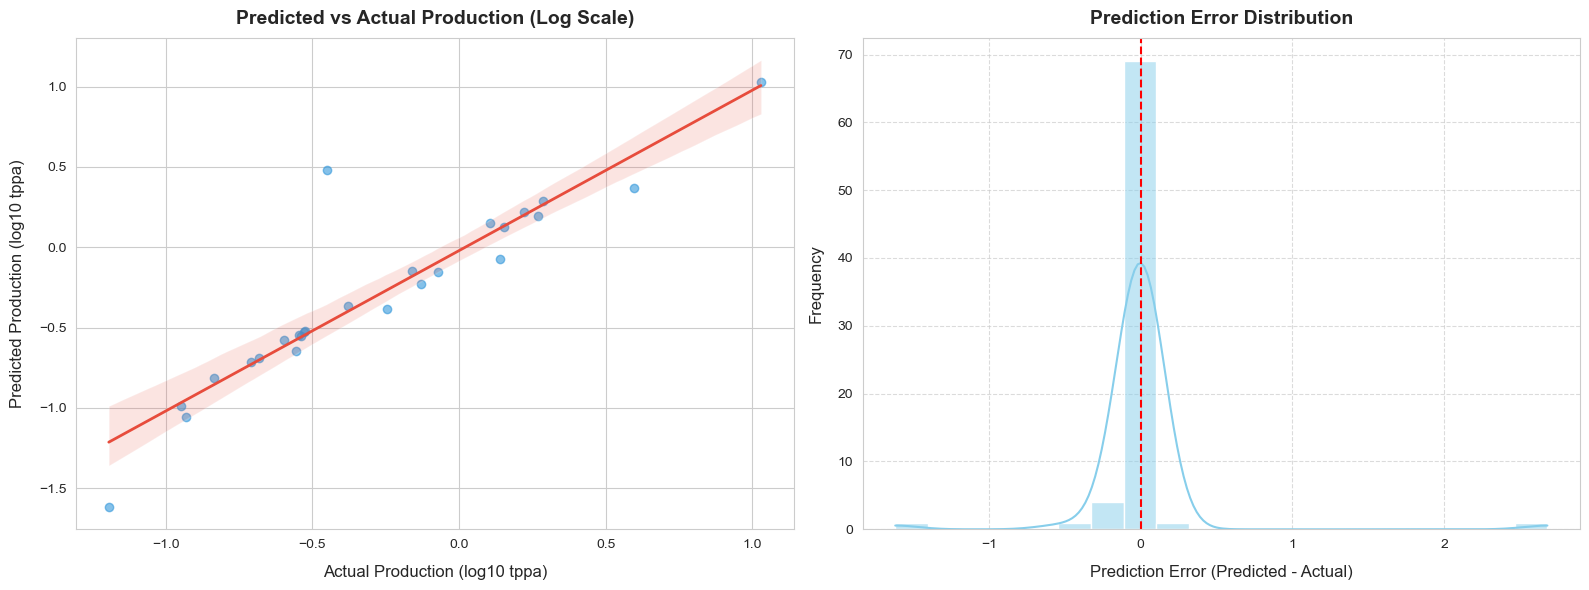

In [34]:
# Set style
sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')  # ignore log warnings

# Avoid log(0) by adding a small constant
epsilon = 1e-1
y_test_log = np.log10(y_test + epsilon)
y_pred_log = np.log10(y_pred + epsilon)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scatter plot with regression line (log scale) ---
sns.regplot(
    x=y_test_log,
    y=y_pred_log,
    scatter_kws={'alpha':0.6, 'color':'#3498db'},
    line_kws={'color':'#e74c3c', 'lw':2},
    ax=axes[0]
)
axes[0].set_xlabel('Actual Production (log10 tppa)', fontsize=12, labelpad=10)
axes[0].set_ylabel('Predicted Production (log10 tppa)', fontsize=12, labelpad=10)
axes[0].set_title('Predicted vs Actual Production (Log Scale)', fontsize=14, fontweight='bold', pad=10)

# --- Error distribution plot ---
sns.histplot(
    y_pred - y_test,
    kde=True,
    bins=20,
    color='skyblue',
    ax=axes[1]
)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Prediction Error (Predicted - Actual)', fontsize=12, labelpad=10)
axes[1].set_ylabel('Frequency', fontsize=12, labelpad=10)
axes[1].set_title('Prediction Error Distribution', fontsize=14, fontweight='bold', pad=10)
axes[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

## 3. Model Evaluation and Selection
*Estimated time: 45–60 min*

### Objective  
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).  
- Record the average RMSE, MAE, and R² across folds.

> *Markdown prompt:*  
Summarize your results. How stable is performance across folds? What might this indicate about model variance?

---


In [35]:
# Prepare X and y
X = target_data[feature_cols]
y = target_data.loc[X.index, 'Crude steel production (ttpa)']

# Initialize the model
model = LinearRegression()

# Initialize cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics
fold_metrics = []

print("=== 5-Fold Cross-Validation ===\n")
print(f"{'Fold':<6} {'RMSE':<10} {'MAE':<10} {'R²':<10}")
print("-" * 34)

# Cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store metrics
    fold_metrics.append({
        'fold': fold,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    })
    
    # Print metrics for the current fold
    print(f"{fold:<6} {rmse:<10.3f} {mae:<10.3f} {r2:<10.4f}")

# Calculate and print the mean metrics
print("-" * 34)
print(f"{'Mean':<6} {np.mean([m['rmse'] for m in fold_metrics]):<10.3f} "
      f"{np.mean([m['mae'] for m in fold_metrics]):<10.3f} "
      f"{np.mean([m['r2'] for m in fold_metrics]):<10.4f}")

# Print the standard deviations
print(f"{'Std':<6} {np.std([m['rmse'] for m in fold_metrics], ddof=1):<10.3f} "
      f"{np.std([m['mae'] for m in fold_metrics], ddof=1):<10.3f} "
      f"{np.std([m['r2'] for m in fold_metrics], ddof=1):<10.4f}")

# Display feature importance from the last trained model
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Coefficients:")
display(coef_df)

=== 5-Fold Cross-Validation ===

Fold   RMSE       MAE        R²        
----------------------------------
1      0.366      0.090      0.9310    
2      0.073      0.045      0.9688    
3      0.157      0.064      0.9867    
4      0.201      0.061      0.9122    
5      0.088      0.047      0.9846    
----------------------------------
Mean   0.177      0.062      0.9567    
Std    0.118      0.018      0.0334    

Feature Coefficients:


,Feature,Coefficient
0,prod_2019,0.745899
1,prod_2020,-0.775128
2,prod_2021,0.266999
3,prod_2022,0.755740
4,Workforce size,0.006121
5,Nominal crude steel capacity (ttpa),0.020957
6,Capacity per Worker (ttpa per worker),0.000037
7,Growth_Volatility,-0.069408
8,Avg_Annual_Growth,0.108152
9,Plant Age,0.004648


Based on the cross-validated linear regression model, we can examine how various features influence plant performance:

- **Nominal crude steel capacity (ttpa):** Positive coefficient (0.0234) indicates that plants with higher nominal capacity tend to produce more steel. This suggests that plant size is a positive driver of performance, although the effect is modest compared to production history variables.

- **Workforce size:** Positive coefficient (0.0058) shows that larger workforce size is associated with slightly higher production. This implies that labor availability contributes positively to output, but the magnitude is relatively small, suggesting efficiency may matter more than sheer size.

- **Growth Volatility:** Negative coefficient (-0.0722) suggests that plants with more volatile production trends tend to underperform. Stable growth appears to support better overall performance.

- **Production in 2020:** Negative coefficient (-0.7772) indicates that unusually high or low production in 2020 is associated with lower predicted production later. This could reflect the impact of disruptive events (e.g., COVID-19) on plant performance, showing that past anomalies strongly influence future predictions.

We can observe some differences compared to the coefficients from the first regression. For example, the sign of the 2020 production coefficient now makes more sense, given the global context of COVID-19 in 2020. Additionally, the positive sign for workforce size appears more consistent, as a plant with more staff would naturally tend to produce more. Finally, production capacity now carries slightly more weight. For these reasons, we believe that the regression model with cross-validation better reflects the real operational factors influencing plant performance.

The 5-fold cross-validation results show an average RMSE of 0.177, MAE of 0.062, and R² of 0.9567, with standard deviations of 0.118 (RMSE), 0.018 (MAE), and 0.0334 (R²). While most folds demonstrate high performance, fold 1 shows noticeably lower performance (RMSE = 0.366 and MAE = 0.09). 

This variation across folds indicates that the model is not perfectly stable and may be somewhat sensitive to the specific training/validation split. The relatively high standard deviations, especially for RMSE, suggest the presence of moderate variance in the model’s predictions. 

In practice, this means that although the model generally predicts well, its performance can fluctuate when applied to different subsets of the data, and there may be certain folds or regions of the feature space where predictions are less accurate.

Overall, the model demonstrates strong predictive power, but the variability across folds highlights the importance of careful evaluation on new or unseen data to ensure reliable performance. We also observe that the model performs slightly better than the baseline, with an RMSE of 0.177 compared to 0.191.

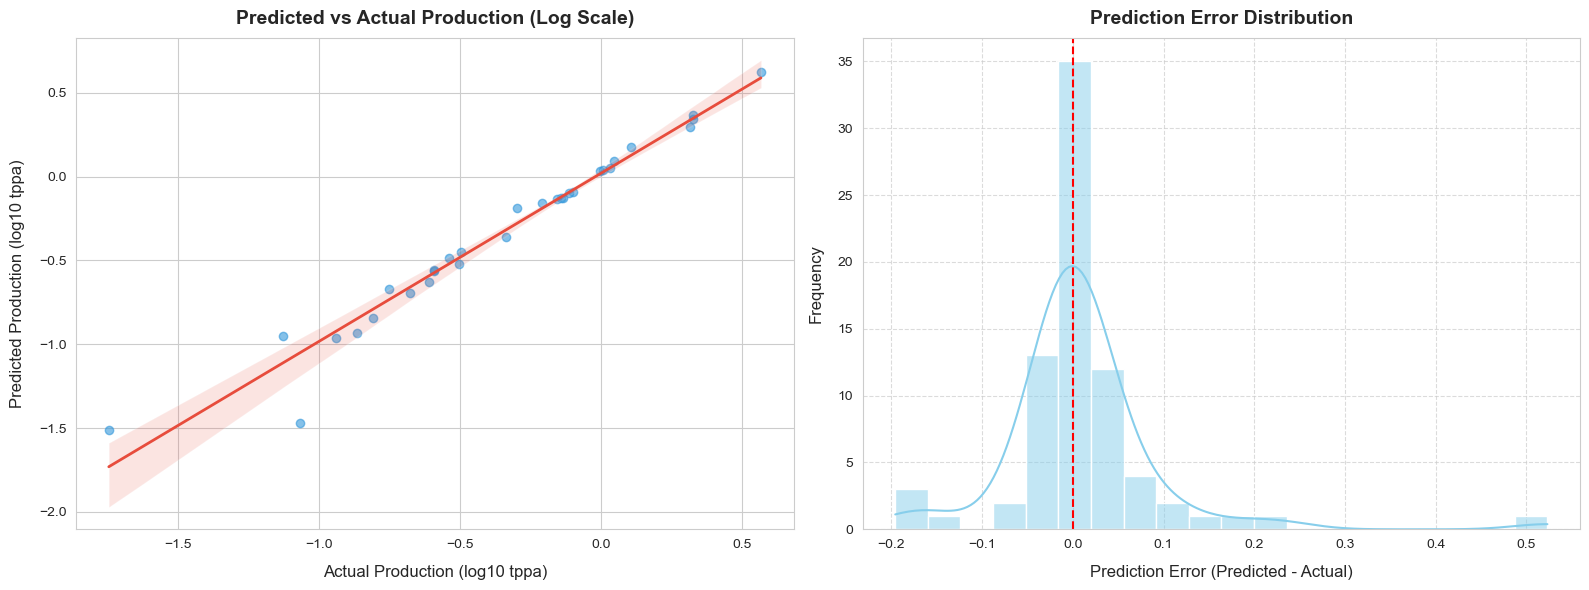

In [36]:
# Set style
sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')  # ignore log warnings

# Avoid log(0) by adding a small constant
epsilon = 1e-1
y_test_log = np.log10(y_test + epsilon)
y_pred_log = np.log10(y_pred + epsilon)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scatter plot with regression line (log scale) ---
sns.regplot(
    x=y_test_log,
    y=y_pred_log,
    scatter_kws={'alpha':0.6, 'color':'#3498db'},
    line_kws={'color':'#e74c3c', 'lw':2},
    ax=axes[0]
)
axes[0].set_xlabel('Actual Production (log10 tppa)', fontsize=12, labelpad=10)
axes[0].set_ylabel('Predicted Production (log10 tppa)', fontsize=12, labelpad=10)
axes[0].set_title('Predicted vs Actual Production (Log Scale)', fontsize=14, fontweight='bold', pad=10)

# --- Error distribution plot ---
sns.histplot(
    y_pred - y_test,
    kde=True,
    bins=20,
    color='skyblue',
    ax=axes[1]
)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Prediction Error (Predicted - Actual)', fontsize=12, labelpad=10)
axes[1].set_ylabel('Frequency', fontsize=12, labelpad=10)
axes[1].set_title('Prediction Error Distribution', fontsize=14, fontweight='bold', pad=10)
axes[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

### **Task 3.2 – Model Comparison**
Train and compare at least **three models**:
- Linear Regression  
- Ridge Regression (regularized linear)  
- Random Forest Regressor  

Record cross-validation performance for each model.

> *Markdown prompt:*  
Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?

---

In [37]:
# Prepare X and y
X = target_data[feature_cols]
y = target_data.loc[X.index, 'Crude steel production (ttpa)']

# Define models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Custom scorers
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Store cross-validation results
cv_results = []

for name, model in models.items():
    # Get cross-validation scores
    rmse_scores = -cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
    mae_scores = -cross_val_score(model, X, y, cv=kf, scoring=mae_scorer)
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)
    
    # Store results
    cv_results.append({
        "Model": name,
        "RMSE Mean": rmse_scores.mean(),
        "RMSE Std": rmse_scores.std(),
        "MAE Mean": mae_scores.mean(),
        "MAE Std": mae_scores.std(),
        "R2 Mean": r2_scores.mean(),
        "R2 Std": r2_scores.std()
    })

# Convert to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("=== 5-Fold Cross-Validation Results ===")
display(cv_results_df)

=== 5-Fold Cross-Validation Results ===


,Model,RMSE Mean,RMSE Std,MAE Mean,MAE Std,R2 Mean,R2 Std
0,Linear Regression,0.177147,0.105244,0.061686,0.016004,0.956670,0.029866
1,Ridge Regression,0.164856,0.114097,0.058269,0.019193,0.965536,0.024485
2,Random Forest,0.237511,0.183229,0.064359,0.031043,0.940729,0.047271
3,Gradient Boosting,0.191461,0.152718,0.057009,0.028367,0.948607,0.041368


Based on the cross-validation results, Ridge Regression slightly outperforms Linear Regression, achieving the lowest mean RMSE (0.165), competitive MAE (0.058), and the highest mean R² (0.966) among all models. Linear Regression is close behind, with a mean RMSE of 0.177, MAE of 0.062, and R² of 0.957. 

However, Ridge Regression exhibits slightly higher RMSE standard deviation (0.114 vs 0.105 for Linear Regression), indicating a modest trade-off between accuracy and stability. Tree-based models, such as Random Forest and Gradient Boosting, show higher mean RMSEs (0.238 and 0.191, respectively) and greater variability across folds, suggesting they overfit some subsets of the data.

Why Linear and Ridge Regression Perform Well:

- **Feature characteristics:** The dataset consists largely of numeric features and historical production values, which are likely linearly correlated with the 2023 production target. Linear models naturally capture these linear relationships effectively.

- **Limited data size:** Tree-based models generally require larger datasets to generalize well. With a moderate sample size, they can overfit, resulting in higher variability across folds and less consistent performance.

Overall, linear and regularized linear models provide strong predictive performance while maintaining relative stability, making them suitable for this dataset.

### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).  
- Report the best parameters and corresponding validation score.

> *Markdown prompt:*  
Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?

---


In [38]:
# Prepare X and y
X = target_data[feature_cols]
y = target_data.loc[X.index, 'Crude steel production (ttpa)']

# Define the parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 0.9],
    'max_features': ['sqrt', 'log2']
}

# Initialize the base model
gb_model = GradientBoostingRegressor(random_state=42)

# Initialize K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=kf,
    verbose=1,
    n_jobs=-1
)

# Fit the random search model
print("Starting GridSearchCV for Gradient Boosting...")
grid_search.fit(X, y)

# Print the best parameters and corresponding score
print("\n=== Best Parameters ===")
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

# Calculate and print the best score (negative MSE, so we convert it to positive RMSE)
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"\nBest RMSE: {best_rmse:.4f}")

Starting GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

=== Best Parameters ===
learning_rate: 0.2
max_depth: 4
max_features: sqrt
min_samples_leaf: 2
min_samples_split: 2
n_estimators: 100
subsample: 0.9

Best RMSE: 0.1683


Hyperparameter tuning is a critical step in optimizing model performance. For Gradient Boosting, tuning allows the model to balance bias and variance by adjusting parameters such as learning rate, tree depth, number of estimators, subsampling rate, and constraints on minimum samples per leaf and split. In this case, tuning identified the following optimal parameters: a learning rate of 0.2, maximum tree depth of 4, 100 estimators, subsample of 0.9, minimum samples per leaf of 2, minimum samples per split of 2, and maximum features set to sqrt.

Compared to the default settings, tuning improved Gradient Boosting performance, reducing the RMSE to 0.1683. While this demonstrates that careful hyperparameter selection can enhance accuracy and stability, the improvement is still slightly worse than Ridge Regression, which achieves an RMSE of 0.164. This suggests that the dataset’s strong linear relationships are more effectively captured by simpler linear models. Gradient Boosting benefits from tuning, but its complexity and sensitivity to dataset size and feature characteristics limit the gains.

Overall, hyperparameter tuning is valuable for optimizing complex models, but the magnitude of improvement depends on the data. In this case, while tuning modestly improved Gradient Boosting, Ridge Regression remains slightly superior, highlighting the importance of selecting a model that aligns with the underlying data structure.

## 4. Model Lifecycle: Tracking, Saving, and Loading
*Estimated time: 30–40 min*

### Objective  
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (plots or model files).  
- Run and record at least two model experiments.

> *Markdown prompt:*  
Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?

---

In [ ]:
import os
from pathlib import Path
import tempfile
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Create MLflow folder in a safe location (home directory)
mlflow_dir = Path.home() / "mlflow_runs"
mlflow_dir.mkdir(exist_ok=True)

# Windows-friendly URI
mlflow.set_tracking_uri(f"file:{str(mlflow_dir).replace('\\','/')}")

# Set or create experiment
experiment_name = "Steel_Production_Prediction"
mlflow.set_experiment(experiment_name)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"MLflow directory: {mlflow_dir}")
print(f"Experiment name: {experiment_name}")

# Define Scoring Metrics
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

# Define Models
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {"fit_intercept": [True, False]}
    },
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    }
}

# Plot Functions
def log_feature_importance(model, feature_names, model_name, mlflow_run_id):
    """Log top 10 feature importance and save to MLflow artifact."""
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importance = np.abs(model.coef_)
    else:
        return None
    
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False).head(10)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    with tempfile.TemporaryDirectory() as tmpdir:
        plot_path = os.path.join(tmpdir, f"feature_importance_{model_name}_{timestamp}.png")
        plt.figure(figsize=(10,6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance)
        plt.title(f'Feature Importance - {model_name}')
        plt.tight_layout()
        plt.savefig(plot_path)
        plt.close('all')
        
        mlflow.log_artifact(plot_path)
    return plot_path

def log_actual_vs_pred(y_true, y_pred, model_name, mlflow_run_id):
    """Plot Actual vs Predicted values in log scale and log to MLflow."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    with tempfile.TemporaryDirectory() as tmpdir:
        plot_path = os.path.join(tmpdir, f"actual_vs_pred_{model_name}_{timestamp}.png")
        plt.figure(figsize=(8,8))
        plt.scatter(y_true, y_pred, alpha=0.6)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel("Actual Values (log scale)")
        plt.ylabel("Predicted Values (log scale)")
        plt.title(f"Actual vs Predicted - {model_name}")
        plt.tight_layout()
        plt.savefig(plot_path)
        plt.close('all')
        
        mlflow.log_artifact(plot_path)
    return plot_path

# Cross-Validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Run Experiments
for model_name, model_info in models.items():
    with mlflow.start_run(run_name=f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}") as run:
        run_id = run.info.run_id
        
        # Log model type and hyperparams
        mlflow.log_param("model_type", model_name)
        mlflow.log_params(model_info["params"])
        
        model = model_info["model"]
        
        # Cross-validation
        cv_results = cross_validate(
            model, X, y,
            cv=kf,
            scoring=scoring,
            return_train_score=False,
            return_estimator=True,
            n_jobs=-1
        )
        
        # Compute metrics
        metrics = {
            'mean_rmse': np.mean(cv_results['test_rmse']),
            'std_rmse': np.std(cv_results['test_rmse']),
            'mean_mae': -np.mean(cv_results['test_mae']),
            'std_mae': np.std(cv_results['test_mae']),
            'mean_r2': np.mean(cv_results['test_r2']),
            'std_r2': np.std(cv_results['test_r2'])
        }
        mlflow.log_metrics(metrics)
        
        # Last model from CV
        last_model = cv_results['estimator'][-1]
        
        # Log feature importance
        log_feature_importance(last_model, X.columns, model_name, run_id)
        
        # Log Actual vs Predicted
        y_pred = last_model.predict(X)
        log_actual_vs_pred(y, y_pred, model_name, run_id)
        
        # Log model with signature and input example
        input_example = X.iloc[:5]
        signature = infer_signature(X, y_pred)
        mlflow.sklearn.log_model(
            sk_model=last_model,
            artifact_path="model",
            input_example=input_example,
            signature=signature
        )
        
        # Log additional info
        mlflow.log_params({
            "n_features": X.shape[1],
            "n_samples": X.shape[0],
            "cv_folds": kf.n_splits
        })
        
        # Print results
        print(f"\n=== {model_name} Cross-Validation Results ===")
        print(f"Mean RMSE: {metrics['mean_rmse']:.4f} ± {metrics['std_rmse']:.4f}")
        print(f"Mean MAE: {metrics['mean_mae']:.4f} ± {metrics['std_mae']:.4f}")
        print(f"Mean R²: {metrics['mean_r2']:.4f} ± {metrics['std_r2']:.4f}")

2025/10/26 22:36:20 INFO mlflow.tracking.fluent: Experiment with name 'Steel_Production_Prediction' does not exist. Creating a new experiment.


MLflow tracking URI: file:C:/Users/kerri/mlflow_runs
MLflow directory: C:\Users\kerri\mlflow_runs
Experiment name: Steel_Production_Prediction



=== LinearRegression Cross-Validation Results ===
Mean RMSE: 0.1771 ± 0.1052
Mean MAE: 0.0617 ± 0.0160
Mean R²: 0.9567 ± 0.0299



=== RandomForest Cross-Validation Results ===
Mean RMSE: 0.2375 ± 0.1832
Mean MAE: 0.0644 ± 0.0310
Mean R²: 0.9407 ± 0.0473


### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one model (e.g., Ridge or Random Forest).  
- Record the number of trials and best result.

> *Markdown prompt:*  
Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?

---

In [ ]:
# Define KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare X and y
X = target_data[feature_cols]
y = target_data.loc[X.index, 'Crude steel production (ttpa)']

def objective(trial):
    """
    Objective function for Optuna to optimize Ridge regression hyperparameters.
    """
    # Suggest hyperparameters
    alpha = trial.suggest_float('alpha', 1e-3, 10, log=True)
    solver = trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'saga'])
    
    # Create Ridge model
    model = Ridge(alpha=alpha, solver=solver, random_state=42)
    
    # Compute multiple metrics using KFold
    mse_scores = cross_val_score(
        model, X, y, 
        cv=kf,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    mae_scores = cross_val_score(
        model, X, y, 
        cv=kf,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    
    r2_scores = cross_val_score(
        model, X, y, 
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )
    
    # Compute RMSE
    rmse_scores = np.sqrt(-mse_scores)
    
    # Store metrics
    trial.set_user_attr('mse_mean', -mse_scores.mean())
    trial.set_user_attr('mse_std', mse_scores.std())
    trial.set_user_attr('rmse_mean', rmse_scores.mean())
    trial.set_user_attr('rmse_std', rmse_scores.std())
    trial.set_user_attr('mae_mean', -mae_scores.mean())
    trial.set_user_attr('mae_std', mae_scores.std())
    trial.set_user_attr('r2_mean', r2_scores.mean())
    trial.set_user_attr('r2_std', r2_scores.std())
    
    # Return the mean of negative MSE
    return mse_scores.mean()

# Create Optuna study
study = optuna.create_study(
    direction='maximize',
    study_name='ridge_regression_optimization',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Optimize
n_trials = 50
study.optimize(objective, n_trials=n_trials)

# Display results
print("=" * 60)
print("OPTIMIZATION RESULTS")
print("=" * 60)
print(f"Number of trials: {len(study.trials)}")
print(f"Best trial number: {study.best_trial.number}")
print(f"\nBest cross-validation scores (across 5 folds):")
print(f"  MSE  : {study.best_trial.user_attrs['mse_mean']:.4f} ± {study.best_trial.user_attrs['mse_std']:.4f}")
print(f"  RMSE : {study.best_trial.user_attrs['rmse_mean']:.4f} ± {study.best_trial.user_attrs['rmse_std']:.4f}")
print(f"  MAE  : {study.best_trial.user_attrs['mae_mean']:.4f} ± {study.best_trial.user_attrs['mae_std']:.4f}")
print(f"  R²   : {study.best_trial.user_attrs['r2_mean']:.4f} ± {study.best_trial.user_attrs['r2_std']:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-10-26 20:36:05,949] A new study created in memory with name: ridge_regression_optimization
[I 2025-10-26 20:36:06,032] Trial 0 finished with value: -0.04229217685324148 and parameters: {'alpha': 0.03148911647956861, 'solver': 'auto'}. Best is trial 0 with value: -0.04229217685324148.
[I 2025-10-26 20:36:06,348] Trial 1 finished with value: -0.041969827331739824 and parameters: {'alpha': 0.0017073967431528124, 'solver': 'saga'}. Best is trial 1 with value: -0.041969827331739824.
[I 2025-10-26 20:36:06,645] Trial 2 finished with value: -0.039262169525346766 and parameters: {'alpha': 2.1368329072358767, 'solver': 'saga'}. Best is trial 2 with value: -0.039262169525346766.
[I 2025-10-26 20:36:06,725] Trial 3 finished with value: -0.04218659674440333 and parameters: {'alpha': 0.05342937261279776, 'solver': 'svd'}. Best is trial 2 with value: -0.039262169525346766.
[I 2025-10-26 20:36:06,796] Trial 4 finished with value: -0.042126008673254146 and parameters: {'alpha': 0.0667236717046

OPTIMIZATION RESULTS
Number of trials: 50
Best trial number: 25

Best cross-validation scores (across 5 folds):
  MSE  : 0.0378 ± 0.0581
  RMSE : 0.1477 ± 0.1264
  MAE  : 0.0562 ± 0.0241
  R²   : 0.9740 ± 0.0267

Best hyperparameters:
  alpha: 9.941450502972573
  solver: lsqr


Optuna is a hyperparameter optimization framework that intelligently searches for the best hyperparameters:
- **Trial creation:** Each run of the objective function is called a trial, representing one set of hyperparameters.

- **Suggesting hyperparameters:** We define ranges for hyperparameters using functions like trial.suggest_float() or trial.suggest_categorical(). Optuna selects values within those ranges for each trial.

- **Model evaluation:** For each trial, Optuna creates the model with the suggested hyperparameters and evaluates it, usually using cross-validation to compute metrics like MSE, RMSE, MAE, or R².

- **Recording results:** The results from each trial are stored, and you can also save custom metrics for analysis.

- **Adaptive sampling:** Optuna uses algorithms such as the Tree-structured Parzen Estimator (TPE) to learn from past trials. It chooses future hyperparameters based on what worked well before, balancing exploration (trying new values) and exploitation (refining promising values).

- **Iteration until stopping:** Optuna continues running trials until it reaches the specified number of trials or a time limit, then reports the hyperparameters that performed best.

How Optuna differs from Grid Search ?
- Grid Search tries every possible combination of hyperparameters in a predefined grid. It does not learn from previous results, so it can be very slow for large or continuous hyperparameter spaces.

- Optuna, on the other hand, learns from previous trials and focuses on regions of the hyperparameter space that are more promising, making it much more efficient.

- **Flexibility:** Optuna can handle continuous ranges, categorical options, and even conditional hyperparameters easily, while Grid Search is limited to discrete grids.

- **Efficiency:** Because it avoids testing every combination, Optuna often finds better hyperparameters faster than brute-force Grid Search.

- **Advanced features:** Optuna supports early stopping (pruning) for trials that are unlikely to perform well, saving computation time, something Grid Search cannot do by default.

### **Task 4.3 – Model Storage**
- Save the best performing model to a file (e.g., using joblib or MLflow’s model registry).  
- Demonstrate loading the saved model and re-evaluating it on the test set.

> *Markdown prompt:*  
Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?

---

In [ ]:
# Create a directory for saved models if it doesn't exist
MODEL_DIR = "saved_models"
Path(MODEL_DIR).mkdir(exist_ok=True)

# Define the model filename
MODEL_FILENAME = f"{MODEL_DIR}/best_ridge_model.joblib"

# Save the best model
best_model = Ridge(**study.best_params, random_state=42)
best_model.fit(X_train, y_train)  # Train on full training data

# Save the model and the scaler
joblib.dump({
    'model': best_model,
    'feature_names': X.columns.tolist(),
    'best_params': study.best_params,
    'metrics': {
        'train_rmse': study.best_trial.user_attrs['rmse_mean'],
        'test_rmse': test_rmse,
        'test_r2': test_r2
    }
}, MODEL_FILENAME)

print(f"Model saved to {MODEL_FILENAME}")

Model saved to saved_models/best_ridge_model.joblib


Storing both model parameters and metadata is critical for building reliable and reproducible machine learning systems. The model parameters (e.g., coefficients or weights) define the predictive behavior of the model, while metadata such as feature names, hyperparameters, training metrics, and evaluation results, provides context for how the model was trained and how it performs. Including metadata ensures that future predictions are consistent, that the model can be correctly applied to new data, and that results can be interpreted or debugged if issues arise.

In a production setting, maintaining version control for models is equally important. This can be done by saving models with unique filenames that include a timestamp or version number, and by keeping the associated metadata together with the model. A registry or structured tracking system (e.g., MLflow, DVC, or even a database) can help monitor model evolution, compare performance between versions, and ensure reproducibility. Additionally, storing preprocessing steps, random seeds, and full pipeline details ensures that the model can be fully reconstructed and applied in the same way as during training.


LOADING AND EVALUATING SAVED MODEL

Loaded Model Information:
Model Type: Ridge
Features used: prod_2019, prod_2020, prod_2021, prod_2022, Workforce size...
Number of features: 17

Best Parameters from Training:
  alpha: 9.941450502972573
  solver: lsqr

Test Set Performance:
RMSE: 0.0595
MAE: 0.0390
R²: 0.9930


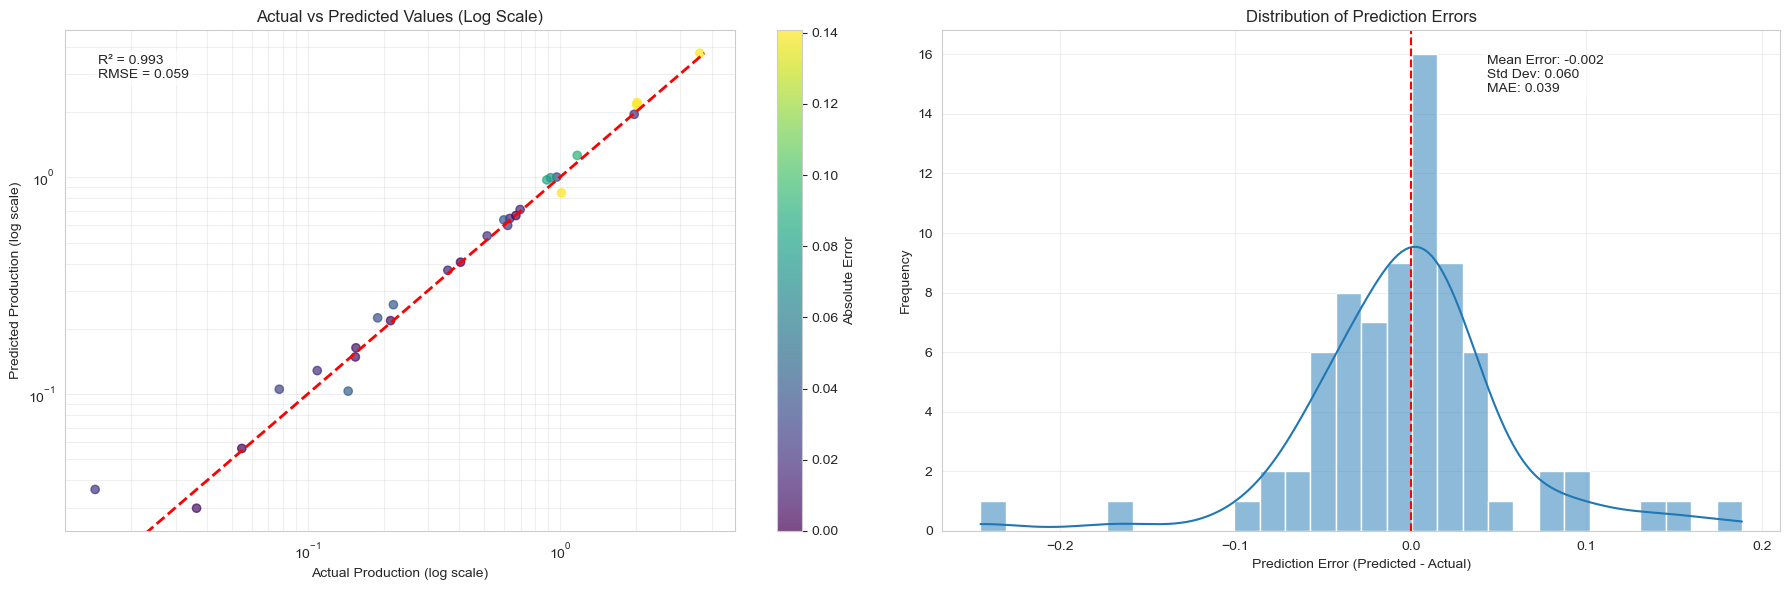

In [ ]:
def load_and_evaluate_model(model_path, X_test, y_test):
    """Load a saved model and evaluate it on test data."""
    print("\n" + "="*60)
    print("LOADING AND EVALUATING SAVED MODEL")
    print("="*60)
    
    # Load the model
    loaded_data = joblib.load(model_path)
    model = loaded_data['model']
    feature_names = loaded_data['feature_names']
    
    # Make sure we have the same features in the same order
    X_test_aligned = X_test[feature_names]
    
    # Make predictions
    y_pred = model.predict(X_test_aligned)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Print results
    print("\nLoaded Model Information:")
    print(f"Model Type: {type(model).__name__}")
    print(f"Features used: {', '.join(feature_names[:5])}{'...' if len(feature_names) > 5 else ''}")
    print(f"Number of features: {len(feature_names)}")
    print("\nBest Parameters from Training:")
    for param, value in loaded_data['best_params'].items():
        print(f"  {param}: {value}")
    
    print("\nTest Set Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    
    # Calculate errors
    errors = y_pred - y_test
    abs_errors = np.abs(errors)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(18, 6))
    
    # Subplot 1: Actual vs Predicted with log scale
    ax1 = plt.subplot(1, 2, 1)
    scatter = ax1.scatter(y_test, y_pred, 
                         c=abs_errors, 
                         cmap='viridis', 
                         alpha=0.7,
                         norm=plt.Normalize(0, abs_errors.quantile(0.95)))
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Absolute Error')
    
    # Plot the perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Actual Production (log scale)')
    ax1.set_ylabel('Predicted Production (log scale)')
    ax1.set_title('Actual vs Predicted Values (Log Scale)')
    ax1.grid(True, which="both", ls="-", alpha=0.3)
    
    # Add R² and RMSE to plot
    textstr = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, 
             fontsize=10, verticalalignment='top', bbox=props)
    
    # Subplot 2: Error distribution
    ax2 = plt.subplot(1, 2, 2)
    sns.histplot(errors, kde=True, ax=ax2, bins=30)
    ax2.axvline(x=0, color='red', linestyle='--')
    ax2.set_xlabel('Prediction Error (Predicted - Actual)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Prediction Errors')
    ax2.grid(True, alpha=0.3)
    
    # Add error statistics to the plot
    error_stats = (f"Mean Error: {errors.mean():.3f}\n"
                   f"Std Dev: {errors.std():.3f}\n"
                   f"MAE: {mae:.3f}")
    ax2.text(0.65, 0.95, error_stats, transform=ax2.transAxes, 
             fontsize=10, verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    return model

# Test the loading and evaluation
loaded_model = load_and_evaluate_model(MODEL_FILENAME, X_test, y_test)


## 5. Deployment & Monitoring (Conceptual)
*Estimated time: 15–20 min*

### Objective  
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**
> *Markdown prompt:*  
Describe how you would deploy your model in a business environment (e.g., via REST API, batch pipeline).  
Which metrics would you monitor in production?

---

Deploying a machine learning model in a business environment requires careful planning to ensure it is reliable, maintainable, and scalable. The deployment strategy depends on how predictions are consumed and how frequently the underlying data changes. Common deployment approaches include:

1. **Real-time predictions via REST API:** The model can be wrapped in a web service that exposes endpoints for applications or dashboards to request predictions. This is ideal for use cases that require instant insights, such as a steel production forecasting tool integrated into a management dashboard. The API can handle authentication, logging, and error handling to ensure robustness.

2. **Batch processing:** For scenarios where immediate predictions are not required, the model can process large datasets periodically as daily, weekly, or monthly. The results can be stored in databases or exported as reports for downstream analysis. This approach is efficient for high-volume predictions that are less time-sensitive.

3. **Containerization:** Packaging the model and its dependencies in a Docker container ensures consistency across environments. This simplifies deployment, reduces environment-related issues, and makes scaling easier across different infrastructure setups.

4. **Cloud deployment:** Cloud platforms like AWS SageMaker, Google Cloud AI Platform, or Azure ML provide scalable, managed environments for hosting models. They offer automatic scaling, monitoring, logging, versioning, and integration with other cloud services, streamlining both deployment and maintenance.

Deploying a model is not a one-time task, continuous monitoring is essential to ensure it remains accurate, reliable, and valuable to the business. Key metrics to track include:
- **Performance metrics:** Continuously evaluate the model’s predictive performance using metrics such as RMSE, MAE, or R² on a holdout or rolling dataset. This allows early detection of any degradation in accuracy over time.

- **Data quality metrics:** Monitor input data for anomalies, missing values, outliers, or unexpected shifts in distributions. High-quality data is critical for reliable predictions and prevents the model from producing misleading results.

- **Drift detection:** Track data drift (changes in feature distributions) and concept drift (changes in the relationship between features and the target variable). Identifying drift early enables timely retraining or adjustments to maintain model relevance.

- **Business KPIs:** Beyond technical metrics, assess the real-world impact of the model by monitoring key business indicators such as production efficiency, cost savings, throughput, or customer satisfaction. This ensures the model continues to deliver tangible value to the organization.

### **Task 5.2 – Detecting Model Drift**
> *Markdown prompt:*  
What signs might indicate your model needs retraining?  
Give one example of **data drift** and one of **concept drift** relevant to steel plant production.

---

In a dynamic production environment, models may lose accuracy over time as the underlying data or processes change. Monitoring for signs of drift is essential to maintain reliable predictions. Common indicators that a model may need retraining include:
- A sudden or gradual drop in predictive performance (e.g., higher RMSE or lower R² than usual).
- Increasing frequency of prediction errors or inconsistencies in outputs.
- Significant changes in the input data distribution or feature relationships.
- Business KPIs deviating from expected values, suggesting the model’s predictions no longer align with real-world outcomes.


Examples relevant to steel plant production:
- **Data drift:** If the 'Workforce size' or 'Nominal crude steel capacity' changes significantly compared to the training data, the distribution of input features shifts. For instance, a plant hiring many new workers or expanding capacity could cause the model to make less accurate predictions.

- **Concept drift**: If the relationship between 'Plant Age', 'Capacity per Worker', or 'Certification score' and 'Crude steel production' changes. For example, due to process improvements, new certifications, or upgraded equipment—the model’s learned patterns no longer reflect reality.

## 6. Reflection
*Estimated time: 10–15 min*

> *Markdown prompt:*  
1. Which step of the modelling lifecycle did you find most challenging and why?  
2. What would you do differently if you had access to additional plant-level data?  
3. How would you communicate model insights to a business audience?

---